**Mashalov Rasulbek, OSTC2U, Machine Learning, HomeWork 8, 16th April, 2026**

In [ ]:
from sklearn.datasets import load_wine, load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

**EXERCISE 1**

In [ ]:
wine = load_wine()
X_wine = wine.data
y_wine = wine.target

#creating Train and Test splits
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_wine, y_wine, test_size=0.2, random_state=2021)

print(f"[INFO] Training set size: {X_train_w.shape[0]}, \nTest set size: {X_test_w.shape[0]}")

[INFO] Training set size: 142, 
Test set size: 36


In [ ]:
# Tree 1: Initializing the tree with no limits
tree_unrestricted = DecisionTreeClassifier(random_state=2021)

#fiting the model to the training data
tree_unrestricted.fit(X_train_w, y_train_w)

#extracting the physical size of the tree
n_nodes = tree_unrestricted.tree_.node_count
max_depth = tree_unrestricted.tree_.max_depth

print(f"\n[INFO] Tree Structure Analysis:")
print(f"  -> Total Number of Nodes: {n_nodes}")
print(f"  -> Maximum Tree Depth: {max_depth}")


[INFO] Tree Structure Analysis:
  -> Total Number of Nodes: 15
  -> Maximum Tree Depth: 5


In [ ]:
#predictions for both sets
y_train_pred = tree_unrestricted.predict(X_train_w)
y_test_pred = tree_unrestricted.predict(X_test_w)

#calculating Accuracies
train_accuracy = accuracy_score(y_train_w, y_train_pred)
test_accuracy = accuracy_score(y_test_w, y_test_pred)

#calculating Errors
train_error = 1.0 - train_accuracy
test_error = 1.0 - test_accuracy

print("[INFO] Unrestricted Tree Performance:")
print(f"  -> Training Accuracy: {train_accuracy * 100:.2f}% | Training Error: {train_error * 100:.2f}%")
print(f"  -> Testing Accuracy:  {test_accuracy * 100:.2f}% | Testing Error:  {test_error * 100:.2f}%")

[INFO] Unrestricted Tree Performance:
  -> Training Accuracy: 100.00% | Training Error: 0.00%
  -> Testing Accuracy:  91.67% | Testing Error:  8.33%


**EXERCISE 2**

In [ ]:
# Tree 2: Limiting the maximum depth
tree_max_depth = DecisionTreeClassifier(max_depth=3, random_state=2021)
tree_max_depth.fit(X_train_w, y_train_w)

# Tree 3: Set minimum samples per leaf to 5
tree_min_samples = DecisionTreeClassifier(min_samples_leaf=5, random_state=2021)
tree_min_samples.fit(X_train_w, y_train_w)

#evaluating all three models
acc_unrestricted = accuracy_score(y_test_w, tree_unrestricted.predict(X_test_w))
acc_max_depth = accuracy_score(y_test_w, tree_max_depth.predict(X_test_w))
acc_min_samples = accuracy_score(y_test_w, tree_min_samples.predict(X_test_w))

print("\n[INFO] Test Set Accuracies:")
print(f"  -> Unrestricted Tree:    {acc_unrestricted * 100:.2f}%")
print(f"  -> Max Depth (3) Tree:   {acc_max_depth * 100:.2f}%")
print(f"  -> Min Samples (5) Tree: {acc_min_samples * 100:.2f}%")


[INFO] Test Set Accuracies:
  -> Unrestricted Tree:    91.67%
  -> Max Depth (3) Tree:   91.67%
  -> Min Samples (5) Tree: 91.67%


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


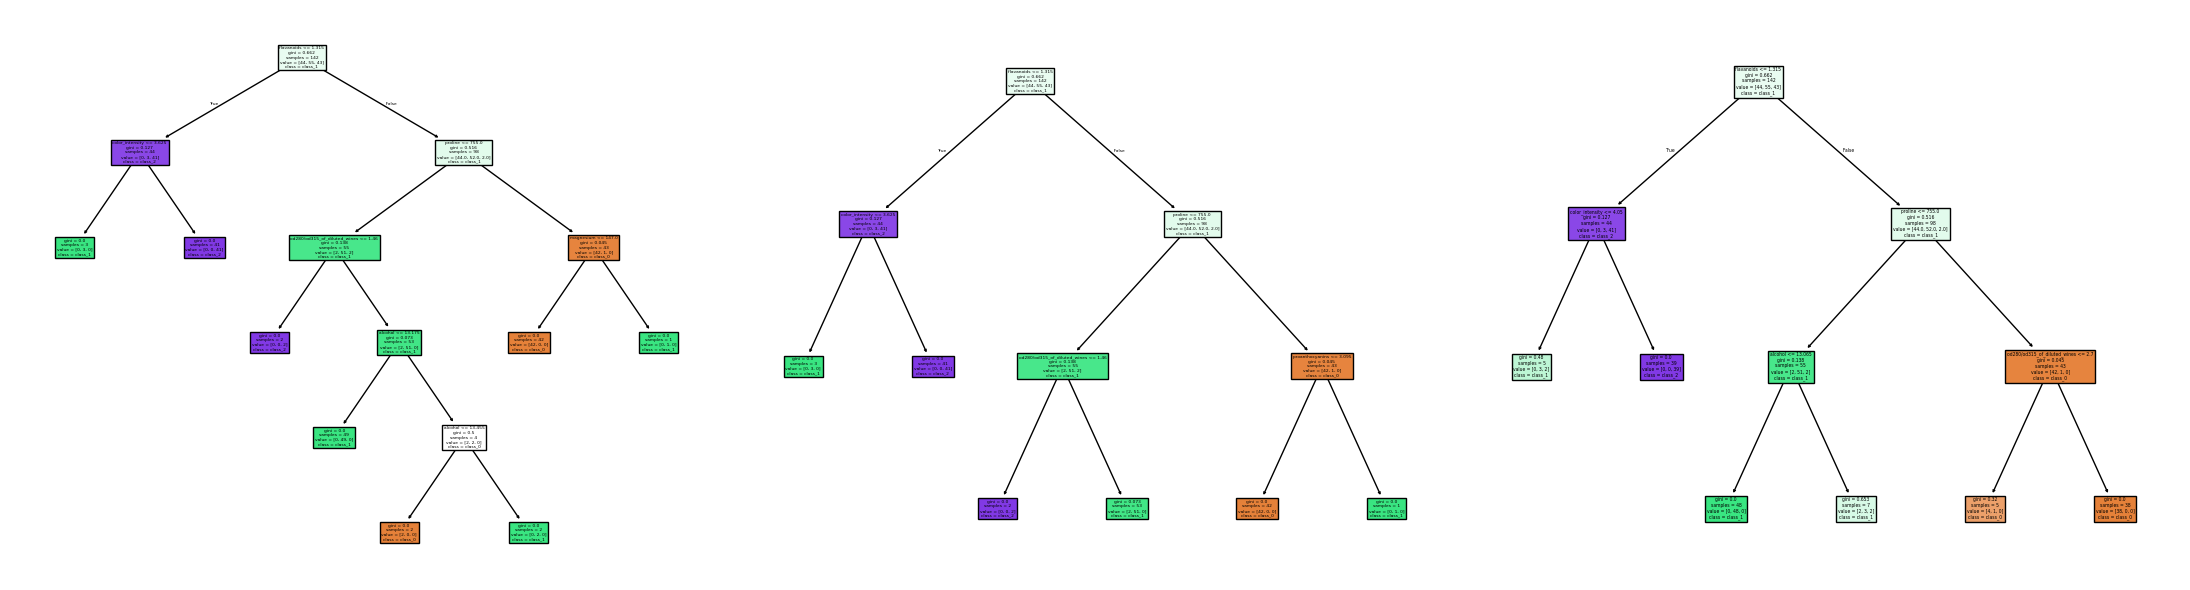

In [ ]:
#setring up a canvas
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(22, 6))

# Tree 1
axes[0].set_title("Tree 1: Unrestricted (Overfitted)", fontsize=14)
plot_tree(tree_unrestricted, filled=True, ax=axes[0], feature_names=wine.feature_names, class_names=wine.target_names)

# Tree 2
axes[1].set_title("Tree 2: max_depth=3", fontsize=14)
plot_tree(tree_max_depth, filled=True, ax=axes[1], feature_names=wine.feature_names, class_names=wine.target_names)

# Tree 3
axes[2].set_title("Tree 3: min_samples_leaf=5", fontsize=14)
plot_tree(tree_min_samples, filled=True, ax=axes[2], feature_names=wine.feature_names, class_names=wine.target_names)

plt.tight_layout()
plt.show()

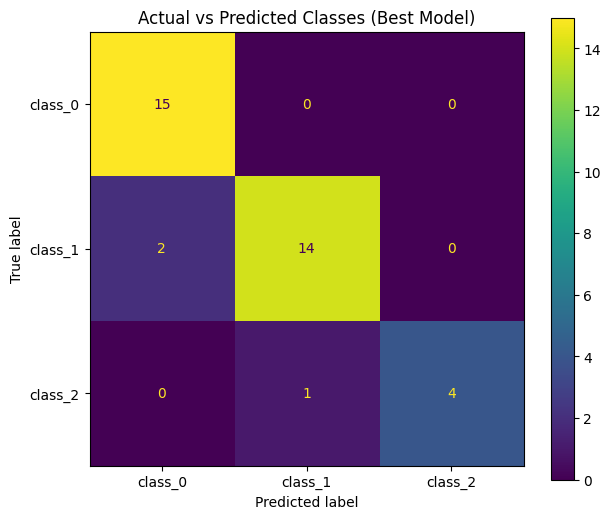

In [ ]:
# We use the max_depth tree as our "Best Model"
best_model = tree_max_depth
y_pred_best = best_model.predict(X_test_w)

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_w,
    y_pred_best,
    display_labels=wine.target_names,
    ax=ax
)

plt.title("Actual vs Predicted Classes (Best Model)")
plt.show()